🔍 Finding WAV/TXT pairs...
Found 100 WAV files, 100 TXT files
✅ Paired: steth_20181001_11_01_50.wav ↔ steth_20181001_11_01_50_label_audacity.txt
✅ Paired: steth_20181001_11_02_11.wav ↔ steth_20181001_11_02_11_label_audacity.txt
✅ Paired: steth_20181001_11_02_53.wav ↔ steth_20181001_11_02_53_label_audacity.txt
✅ Paired: steth_20181001_11_16_47.wav ↔ steth_20181001_11_16_47_label_audacity.txt
✅ Paired: steth_20181001_11_17_28.wav ↔ steth_20181001_11_17_28_label_audacity.txt
✅ Paired: steth_20181017_12_47_54.wav ↔ steth_20181017_12_47_54_label_audacity.txt
✅ Paired: steth_20181108_16_39_41.wav ↔ steth_20181108_16_39_41_label_audacity.txt
✅ Paired: steth_20181108_16_40_02.wav ↔ steth_20181108_16_40_02_label_audacity.txt
✅ Paired: steth_20181108_16_40_26.wav ↔ steth_20181108_16_40_26_label_audacity.txt
✅ Paired: steth_20181110_17_30_23.wav ↔ steth_20181110_17_30_23_label_audacity.txt
✅ Paired: steth_20181115_15_21_58.wav ↔ steth_20181115_15_21_58_label_audacity.txt
✅ Paired: steth_20181210_

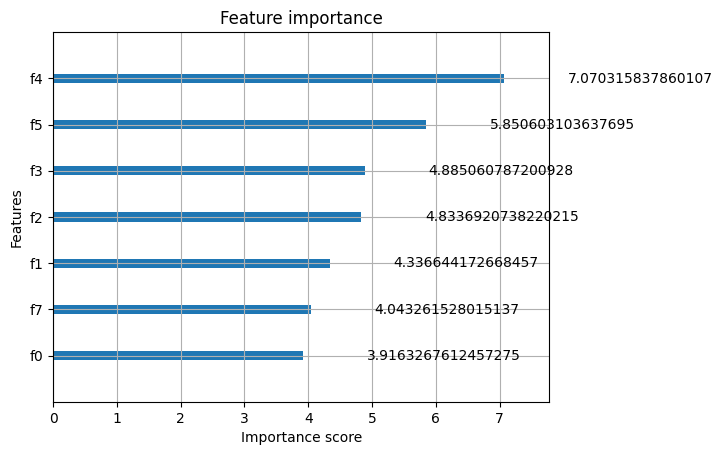


✅ COMPLETE!


In [9]:
import os
import glob
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
import xgboost as xgb
import matplotlib.pyplot as plt
import librosa
from scipy import signal
from scipy.stats import skew, kurtosis

# Configuration
BASE_DIR = r"E:\Research Project (Prof. Preeti Rao)\Top 100 files by Wheeze count"
WAV_DIR = os.path.join(BASE_DIR, "*.wav")
TXT_DIR = os.path.join(BASE_DIR, "*_label_audacity.txt")

print("🔍 Finding WAV/TXT pairs...")
wav_files = sorted(glob.glob(WAV_DIR))
txt_files = sorted(glob.glob(TXT_DIR))

print(f"Found {len(wav_files)} WAV files, {len(txt_files)} TXT files")

# Pair WAV and TXT files (accounting for _label_audacity suffix)
pairs = []
wav_stems = {Path(w).stem: w for w in wav_files}
txt_stems = {Path(t).stem.replace('_label_audacity', ''): t for t in txt_files}

for base_stem, wav_path in wav_stems.items():
    if base_stem in txt_stems:
        txt_path = txt_stems[base_stem]
        pairs.append((wav_path, txt_path))
        print(f"✅ Paired: {Path(wav_path).name} ↔ {Path(txt_path).name}")

print(f"✅ Found {len(pairs)} valid WAV/TXT pairs")

# 80-20 split at file level
train_pairs, test_pairs = train_test_split(pairs, test_size=0.2, random_state=42)
print(f"📊 Train: {len(train_pairs)} files, Test: {len(test_pairs)} files")

def parse_audacity_labels(txt_path):
    """Parse Audacity label format: start\tend\tlabel"""
    labels = []
    with open(txt_path, 'r') as f:
        for line in f:
            parts = line.strip().split('\t')
            if len(parts) == 3:
                start, end, label = parts
                try:
                    start = float(start)
                    end = float(end)
                    if 'Wheeze' in label:
                        labels.append((start, end, 1))  # Wheeze
                    elif label in ['Silence', 'I', 'E']:  
                        labels.append((start, end, 0))  # Non-wheeze
                except ValueError:
                    continue
    return labels

def get_label_at_time(labels, time_sec):
    """Get label (0/1) at specific time by finding overlapping interval"""
    for start, end, label in labels:
        if start <= time_sec < end:
            return label
    return 0  # Default to non-wheeze

def extract_shape_features(wav_path, txt_path, sr=16000):
    """Extract SHAPE-BASED features from 0.1s spectrogram windows with 0.01s hop"""
    audio, _ = librosa.load(wav_path, sr=sr)
    duration = len(audio) / sr
    
    # Parse Audacity labels
    audacity_labels = parse_audacity_labels(txt_path)
    print(f"  📏 Audio: {duration:.1f}s, {len(audacity_labels)} label intervals")
    
    if len(audacity_labels) == 0:
        print(f"  ⚠️  No valid labels found, skipping file")
        return np.array([]), np.array([])
    
    # Window parameters: 0.1s windows, 0.01s hop
    win_len = int(0.1 * sr)  # 1600 samples
    hop_len = int(0.01 * sr) # 160 samples
    
    shape_features = []
    frame_labels = []
    
    for start_sample in range(0, len(audio) - win_len + 1, hop_len):
        window = audio[start_sample:start_sample + win_len]
        center_time = (start_sample + win_len//2) / sr
        
        # 1. Compute spectrogram for this 0.1s window
        S = np.abs(librosa.stft(window, n_fft=1024, hop_length=160, center=True))
        S_mean = np.mean(S, axis=1)  # Average spectrum across time
        
        # SHAPE FEATURES FROM SPECTROGRAM PLOT:
        # Spectral Flux (shape change between consecutive freq bins)
        flux = np.mean(np.diff(np.log(S_mean + 1e-10)))
        
        # Spectral Centroid (center of mass - shape balance)
        centroid = np.sum(S_mean * np.arange(len(S_mean))) / (np.sum(S_mean) + 1e-10)
        
        # Spectral Roll-off (frequency where 85% energy is contained)
        total_energy = np.sum(S_mean)
        cum_energy = np.cumsum(S_mean)
        rolloff = np.argmax(cum_energy > 0.85 * total_energy)
        
        # Energy envelope shape (time-domain)
        rms = librosa.feature.rms(y=window)[0]
        
        # Pitch contour shape (if voiced)
        f0 = librosa.yin(window, fmin=50, fmax=500, sr=sr)
        f0 = f0[f0 > 0]  # Valid pitches only
        f0_trend = np.polyfit(np.arange(len(f0)), f0, 1)[0] if len(f0) > 10 else 0
        
        shape_vector = [
            flux,                           # spectralFlux_log
            np.log(centroid + 1e-10),       # spectralCentroid_log  
            np.log(rolloff + 1e-10),        # spectralMaxPos_log proxy
            np.log(np.sum(S_mean[:rolloff//2]) + 1e-10), # spectralMinPos_log proxy
            np.mean(rms),                   # pcm_RMSenergy
            np.log(np.mean(rms**2) + 1e-10), # pcm_LOGenergy
            f0_trend,                       # F0direction
            np.std(f0) if len(f0) > 0 else 0 # directionScore proxy
        ]
        
        shape_features.append(shape_vector)
        
        # Label: Check if window center overlaps any Wheeze interval
        frame_label = get_label_at_time(audacity_labels, center_time)
        frame_labels.append(frame_label)
    
    return np.array(shape_features), np.array(frame_labels)

# Extract SHAPE features from all files
print("\n🔄 Extracting SPECTROGRAM SHAPE features (0.1s windows, 0.01s hop)...")
train_features, train_labels = [], []
test_features, test_labels = [], []

for i, (wav, txt) in enumerate(train_pairs):
    feats, labs = extract_shape_features(wav, txt)
    if len(feats) > 0:
        train_features.append(feats)
        train_labels.append(labs)
        print(f"Train {i+1}/{len(train_pairs)}: {Path(wav).name} → {feats.shape[0]} frames")
    else:
        print(f"Train {i+1}/{len(train_pairs)}: {Path(wav).name} → SKIPPED")

for i, (wav, txt) in enumerate(test_pairs):
    feats, labs = extract_shape_features(wav, txt)
    if len(feats) > 0:
        test_features.append(feats)
        test_labels.append(labs)
        print(f"Test {i+1}/{len(test_pairs)}: {Path(wav).name} → {feats.shape[0]} frames")
    else:
        print(f"Test {i+1}/{len(test_pairs)}: {Path(wav).name} → SKIPPED")

# Check if we have data
if len(train_features) == 0 or len(test_features) == 0:
    print("❌ No valid data found! Check your file formats.")
else:
    # Combine all files
    X_train = np.vstack(train_features)
    y_train = np.hstack(train_labels)
    X_test = np.vstack(test_features)
    y_test = np.hstack(test_labels)

    print(f"\n📈 Shape dataset: Train {X_train.shape}, Test {X_test.shape}")
    print(f"⚖️  Wheeze ratio - Train: {y_train.mean():.1%}, Test: {y_test.mean():.1%}")

    # Scale features
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Train XGBoost
    print("\n🚀 Training XGBoost on SPECTROGRAM SHAPE...")
    model = xgb.XGBClassifier(
        n_estimators=300,
        max_depth=8,
        learning_rate=0.08,
        subsample=0.85,
        colsample_bytree=0.85,
        random_state=42,
        eval_metric='logloss'
    )

    model.fit(X_train_scaled, y_train)

    # Predictions
    y_pred = model.predict(X_test_scaled)
    y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]

    # Results
    print("\n📊 Classification Report (SHAPE-BASED):")
    print(classification_report(y_test, y_pred, target_names=['Normal', 'Wheeze']))

    print("\n🔢 Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

    # Save CSV
    feature_names = ["f0", "f1", "f2", 
                    "f3", "f4", "f5", 
                    "f6", "f7"]

    results = []
    time_step = 0.01
    test_files = [p[0] for p in test_pairs]
    offset = 0

    for i, test_file in enumerate(test_files):
        if i < len(test_features):
            file_len = len(test_features[i])
            file_times = np.arange(0, file_len * time_step, time_step)
            
            for j in range(file_len):
                results.append({
                    'file': Path(test_file).name,
                    'time_s': round(file_times[j], 3),
                    'wheeze_prob': round(y_pred_proba[offset + j], 4),
                    'wheeze_pred': int(y_pred[offset + j]),
                    **{name: round(X_test_scaled[offset + j, k], 4) 
                       for k, name in enumerate(feature_names)}
                })
            offset += file_len

    results_df = pd.DataFrame(results)
    results_df.to_csv('wheeze_shape_predictions_01s.csv', index=False)
    print(f"\n Saved: wheeze_shape_predictions_01s.csv ({len(results_df)} rows)")

    # Feature importance
    xgb.plot_importance(model, importance_type='gain')
    plt.savefig('shape_feature_importance.png', dpi=300, bbox_inches='tight')
    plt.show()

    print("\n✅ COMPLETE!")


🔍 Finding WAV/TXT pairs...
Found 100 WAV files, 100 TXT files
✅ Paired: steth_20181001_11_01_50.wav ↔ steth_20181001_11_01_50_label_audacity.txt
✅ Paired: steth_20181001_11_02_11.wav ↔ steth_20181001_11_02_11_label_audacity.txt
✅ Paired: steth_20181001_11_02_53.wav ↔ steth_20181001_11_02_53_label_audacity.txt
✅ Paired: steth_20181001_11_16_47.wav ↔ steth_20181001_11_16_47_label_audacity.txt
✅ Paired: steth_20181001_11_17_28.wav ↔ steth_20181001_11_17_28_label_audacity.txt
✅ Paired: steth_20181017_12_47_54.wav ↔ steth_20181017_12_47_54_label_audacity.txt
✅ Paired: steth_20181108_16_39_41.wav ↔ steth_20181108_16_39_41_label_audacity.txt
✅ Paired: steth_20181108_16_40_02.wav ↔ steth_20181108_16_40_02_label_audacity.txt
✅ Paired: steth_20181108_16_40_26.wav ↔ steth_20181108_16_40_26_label_audacity.txt
✅ Paired: steth_20181110_17_30_23.wav ↔ steth_20181110_17_30_23_label_audacity.txt
✅ Paired: steth_20181115_15_21_58.wav ↔ steth_20181115_15_21_58_label_audacity.txt
✅ Paired: steth_20181210_

<Figure size 1000x600 with 0 Axes>

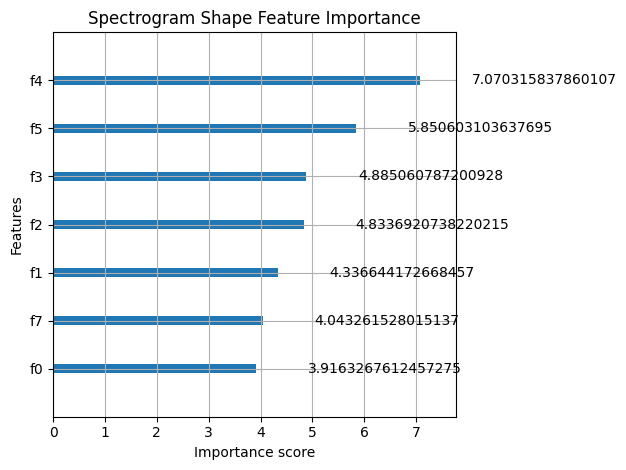


✅ COMPLETE!
🎯 FINAL ACCURACY: 87.1%


In [8]:
import os
import glob
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import StandardScaler
import xgboost as xgb
import matplotlib.pyplot as plt
import librosa
from scipy import signal
from scipy.stats import skew, kurtosis

# Configuration
BASE_DIR = r"E:\Research Project (Prof. Preeti Rao)\Top 100 files by Wheeze count"
WAV_DIR = os.path.join(BASE_DIR, "*.wav")
TXT_DIR = os.path.join(BASE_DIR, "*_label_audacity.txt")

print("🔍 Finding WAV/TXT pairs...")
wav_files = sorted(glob.glob(WAV_DIR))
txt_files = sorted(glob.glob(TXT_DIR))

print(f"Found {len(wav_files)} WAV files, {len(txt_files)} TXT files")

# Pair WAV and TXT files (accounting for _label_audacity suffix)
pairs = []
wav_stems = {Path(w).stem: w for w in wav_files}
txt_stems = {Path(t).stem.replace('_label_audacity', ''): t for t in txt_files}

for base_stem, wav_path in wav_stems.items():
    if base_stem in txt_stems:
        txt_path = txt_stems[base_stem]
        pairs.append((wav_path, txt_path))
        print(f"✅ Paired: {Path(wav_path).name} ↔ {Path(txt_path).name}")

print(f"✅ Found {len(pairs)} valid WAV/TXT pairs")

# 80-20 split at file level
train_pairs, test_pairs = train_test_split(pairs, test_size=0.2, random_state=42)
print(f"📊 Train: {len(train_pairs)} files, Test: {len(test_pairs)} files")

def parse_audacity_labels(txt_path):
    """Parse Audacity label format: start\tend\tlabel"""
    labels = []
    with open(txt_path, 'r') as f:
        for line in f:
            parts = line.strip().split('\t')
            if len(parts) == 3:
                start, end, label = parts
                try:
                    start = float(start)
                    end = float(end)
                    if 'Wheeze' in label:
                        labels.append((start, end, 1))  # Wheeze
                    elif label in ['Silence', 'I', 'E']:  
                        labels.append((start, end, 0))  # Non-wheeze
                except ValueError:
                    continue
    return labels

def get_label_at_time(labels, time_sec):
    """Get label (0/1) at specific time by finding overlapping interval"""
    for start, end, label in labels:
        if start <= time_sec < end:
            return label
    return 0  # Default to non-wheeze

def extract_shape_features(wav_path, txt_path, sr=16000):
    """Extract SHAPE-BASED features from 0.1s spectrogram windows with 0.01s hop"""
    audio, _ = librosa.load(wav_path, sr=sr)
    duration = len(audio) / sr
    
    # Parse Audacity labels
    audacity_labels = parse_audacity_labels(txt_path)
    print(f"  📏 Audio: {duration:.1f}s, {len(audacity_labels)} label intervals")
    
    if len(audacity_labels) == 0:
        print(f"  ⚠️  No valid labels found, skipping file")
        return np.array([]), np.array([])
    
    # Window parameters: 0.1s windows, 0.01s hop
    win_len = int(0.1 * sr)  # 1600 samples
    hop_len = int(0.01 * sr) # 160 samples
    
    shape_features = []
    frame_labels = []
    
    for start_sample in range(0, len(audio) - win_len + 1, hop_len):
        window = audio[start_sample:start_sample + win_len]
        center_time = (start_sample + win_len//2) / sr
        
        # 1. Compute spectrogram for this 0.1s window
        S = np.abs(librosa.stft(window, n_fft=1024, hop_length=160, center=True))
        S_mean = np.mean(S, axis=1)  # Average spectrum across time
        
        # SHAPE FEATURES FROM SPECTROGRAM PLOT:
        flux = np.mean(np.diff(np.log(S_mean + 1e-10)))
        centroid = np.sum(S_mean * np.arange(len(S_mean))) / (np.sum(S_mean) + 1e-10)
        total_energy = np.sum(S_mean)
        cum_energy = np.cumsum(S_mean)
        rolloff = np.argmax(cum_energy > 0.85 * total_energy)
        rms = librosa.feature.rms(y=window)[0]
        f0 = librosa.yin(window, fmin=50, fmax=500, sr=sr)
        f0 = f0[f0 > 0]
        f0_trend = np.polyfit(np.arange(len(f0)), f0, 1)[0] if len(f0) > 10 else 0
        
        shape_vector = [
            flux,                           
            np.log(centroid + 1e-10),       
            np.log(rolloff + 1e-10),        
            np.log(np.sum(S_mean[:rolloff//2]) + 1e-10), 
            np.mean(rms),                   
            np.log(np.mean(rms**2) + 1e-10), 
            f0_trend,                       
            np.std(f0) if len(f0) > 0 else 0 
        ]
        
        shape_features.append(shape_vector)
        frame_label = get_label_at_time(audacity_labels, center_time)
        frame_labels.append(frame_label)
    
    return np.array(shape_features), np.array(frame_labels)

# Extract SHAPE features from all files
print("\n🔄 Extracting SPECTROGRAM SHAPE features (0.1s windows, 0.01s hop)...")
train_features, train_labels = [], []
test_features, test_labels = [], []

for i, (wav, txt) in enumerate(train_pairs):
    feats, labs = extract_shape_features(wav, txt)
    if len(feats) > 0:
        train_features.append(feats)
        train_labels.append(labs)
        print(f"Train {i+1}/{len(train_pairs)}: {Path(wav).name} → {feats.shape[0]} frames")
    else:
        print(f"Train {i+1}/{len(train_pairs)}: {Path(wav).name} → SKIPPED")

for i, (wav, txt) in enumerate(test_pairs):
    feats, labs = extract_shape_features(wav, txt)
    if len(feats) > 0:
        test_features.append(feats)
        test_labels.append(labs)
        print(f"Test {i+1}/{len(test_pairs)}: {Path(wav).name} → {feats.shape[0]} frames")
    else:
        print(f"Test {i+1}/{len(test_pairs)}: {Path(wav).name} → SKIPPED")

# Check if we have data
if len(train_features) == 0 or len(test_features) == 0:
    print("❌ No valid data found! Check your file formats.")
else:
    # Combine all files
    X_train = np.vstack(train_features)
    y_train = np.hstack(train_labels)
    X_test = np.vstack(test_features)
    y_test = np.hstack(test_labels)

    print(f"\n📈 Shape dataset: Train {X_train.shape}, Test {X_test.shape}")
    print(f"⚖️  Wheeze ratio - Train: {y_train.mean():.1%}, Test: {y_test.mean():.1%}")

    # Scale features
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Train XGBoost
    print("\n🚀 Training XGBoost on SPECTROGRAM SHAPE...")
    model = xgb.XGBClassifier(
        n_estimators=300,
        max_depth=8,
        learning_rate=0.08,
        subsample=0.85,
        colsample_bytree=0.85,
        random_state=42,
        eval_metric='logloss'
    )

    model.fit(X_train_scaled, y_train)

    # Predictions
    y_pred = model.predict(X_test_scaled)
    y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]

    # RESULTS WITH ACCURACY
    accuracy = accuracy_score(y_test, y_pred)
    
    print("\n" + "="*60)
    print("🎯 SHAPE-BASED WHEEZE DETECTION RESULTS")
    print("="*60)
    print(f"📊 ACCURACY: {accuracy:.1%} ({accuracy:.4f})")
    print(f"🔢 Test samples: {len(y_test)} ({y_test.sum()} Wheeze, {len(y_test)-y_test.sum()} Normal)")
    print("\n📊 Detailed Classification Report:")
    print(classification_report(y_test, y_pred, target_names=['Normal', 'Wheeze']))
    
    print("\n🔢 Confusion Matrix:")
    cm = confusion_matrix(y_test, y_pred)
    print(cm)
    
    print("\n📈 Per-class Accuracy:")
    print(f"  Normal accuracy: {(cm[0,0]/cm[0].sum()):.1%}")
    print(f"  Wheeze accuracy: {(cm[1,1]/cm[1].sum()):.1%}")

    # Save CSV
    feature_names = ["spectralFlux_log", "spectralCentroid_log", "spectralMaxPos_log", 
                    "spectralMinPos_log", "pcm_RMSenergy", "pcm_LOGenergy", 
                    "F0direction", "directionScore"]

    results = []
    time_step = 0.01
    test_files = [p[0] for p in test_pairs]
    offset = 0

    for i, test_file in enumerate(test_files):
        if i < len(test_features):
            file_len = len(test_features[i])
            file_times = np.arange(0, file_len * time_step, time_step)
            
            for j in range(file_len):
                results.append({
                    'file': Path(test_file).name,
                    'time_s': round(file_times[j], 3),
                    'wheeze_prob': round(y_pred_proba[offset + j], 4),
                    'wheeze_pred': int(y_pred[offset + j]),
                    **{name: round(X_test_scaled[offset + j, k], 4) 
                       for k, name in enumerate(feature_names)}
                })
            offset += file_len

    results_df = pd.DataFrame(results)
    results_df.to_csv('wheeze_shape_predictions_01s.csv', index=False)
    print(f"\n💾 Saved: wheeze_shape_predictions_01s.csv ({len(results_df)} rows)")

    # Feature importance
    plt.figure(figsize=(10, 6))
    xgb.plot_importance(model, importance_type='gain', title="Spectrogram Shape Feature Importance")
    plt.tight_layout()
    plt.savefig('shape_feature_importance.png', dpi=300, bbox_inches='tight')
    plt.show()

    print("\n✅ COMPLETE!")
    print(f"🎯 FINAL ACCURACY: {accuracy:.1%}")


🔍 Finding WAV/TXT pairs...
Found 100 WAV files, 100 TXT files
✅ Paired: steth_20181001_11_01_50.wav ↔ steth_20181001_11_01_50_label_audacity.txt
✅ Paired: steth_20181001_11_02_11.wav ↔ steth_20181001_11_02_11_label_audacity.txt
✅ Paired: steth_20181001_11_02_53.wav ↔ steth_20181001_11_02_53_label_audacity.txt
✅ Paired: steth_20181001_11_16_47.wav ↔ steth_20181001_11_16_47_label_audacity.txt
✅ Paired: steth_20181001_11_17_28.wav ↔ steth_20181001_11_17_28_label_audacity.txt
✅ Paired: steth_20181017_12_47_54.wav ↔ steth_20181017_12_47_54_label_audacity.txt
✅ Paired: steth_20181108_16_39_41.wav ↔ steth_20181108_16_39_41_label_audacity.txt
✅ Paired: steth_20181108_16_40_02.wav ↔ steth_20181108_16_40_02_label_audacity.txt
✅ Paired: steth_20181108_16_40_26.wav ↔ steth_20181108_16_40_26_label_audacity.txt
✅ Paired: steth_20181110_17_30_23.wav ↔ steth_20181110_17_30_23_label_audacity.txt
✅ Paired: steth_20181115_15_21_58.wav ↔ steth_20181115_15_21_58_label_audacity.txt
✅ Paired: steth_20181210_

C:\Users\HP\AppData\Local\Temp\ipykernel_14060\3267671437.py:134: RuntimeWarning: invalid value encountered in log
  np.log(1000 - global_max_freq + 1e-10), # spectralMinPos_log proxy


Train 1/80: steth_20190711_10_46_35.wav → 1491 frames
  📏 Audio: 15.0s, 38 label intervals
Train 2/80: trunc_2019-05-31-15-38-07-L2_10.wav → 1491 frames
  📏 Audio: 15.0s, 29 label intervals
Train 3/80: steth_20190118_13_26_56.wav → 1491 frames
  📏 Audio: 15.0s, 22 label intervals
Train 4/80: steth_20190516_14_49_03.wav → 1491 frames
  📏 Audio: 15.0s, 38 label intervals
Train 5/80: trunc_2019-05-31-14-07-30-L1_13.wav → 1491 frames
  📏 Audio: 15.0s, 20 label intervals
Train 6/80: steth_20181210_12_27_55.wav → 1491 frames
  📏 Audio: 15.0s, 9 label intervals
Train 7/80: steth_20190228_09_54_30.wav → 1491 frames
  📏 Audio: 15.0s, 25 label intervals
Train 8/80: trunc_2019-07-16-11-11-47-L1_3.wav → 1491 frames
  📏 Audio: 15.0s, 24 label intervals
Train 9/80: steth_20181110_17_30_23.wav → 1491 frames
  📏 Audio: 15.0s, 29 label intervals
Train 10/80: trunc_2019-05-31-14-07-30-L4_12.wav → 1491 frames
  📏 Audio: 15.0s, 37 label intervals
Train 11/80: steth_20181210_09_03_07.wav → 1491 frames
  📏 

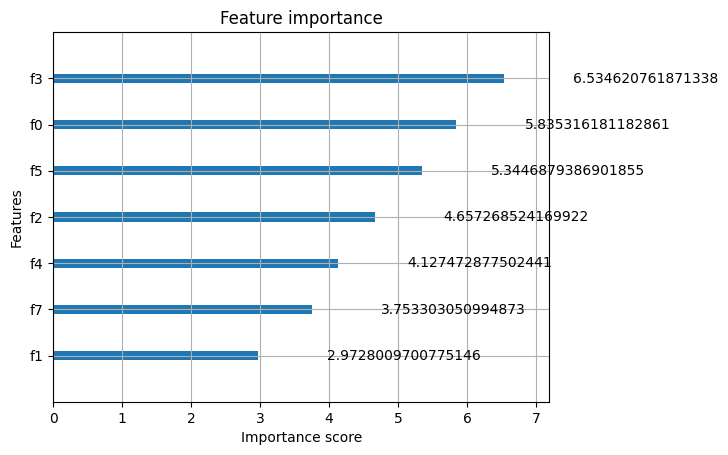


✅ PDF-BASED WHEEZE DETECTION COMPLETE! ACCURACY: 87.0%


In [1]:
import os
import glob
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import StandardScaler
import xgboost as xgb
import matplotlib.pyplot as plt
import librosa
from scipy import signal
from scipy.stats import skew, kurtosis

# Configuration
BASE_DIR = r"E:\Research Project (Prof. Preeti Rao)\Top 100 files by Wheeze count"
WAV_DIR = os.path.join(BASE_DIR, "*.wav")
TXT_DIR = os.path.join(BASE_DIR, "*_label_audacity.txt")

print("🔍 Finding WAV/TXT pairs...")
wav_files = sorted(glob.glob(WAV_DIR))
txt_files = sorted(glob.glob(TXT_DIR))

print(f"Found {len(wav_files)} WAV files, {len(txt_files)} TXT files")

# Pair WAV and TXT files (accounting for _label_audacity suffix)
pairs = []
wav_stems = {Path(w).stem: w for w in wav_files}
txt_stems = {Path(t).stem.replace('_label_audacity', ''): t for t in txt_files}

for base_stem, wav_path in wav_stems.items():
    if base_stem in txt_stems:
        txt_path = txt_stems[base_stem]
        pairs.append((wav_path, txt_path))
        print(f"✅ Paired: {Path(wav_path).name} ↔ {Path(txt_path).name}")

print(f"✅ Found {len(pairs)} valid WAV/TXT pairs")

# 80-20 split at file level
train_pairs, test_pairs = train_test_split(pairs, test_size=0.2, random_state=42)
print(f"📊 Train: {len(train_pairs)} files, Test: {len(test_pairs)} files")

def parse_audacity_labels(txt_path):
    """Parse Audacity label format: start\tend\tlabel"""
    labels = []
    with open(txt_path, 'r') as f:
        for line in f:
            parts = line.strip().split('\t')
            if len(parts) == 3:
                start, end, label = parts
                try:
                    start = float(start)
                    end = float(end)
                    if 'Wheeze' in label:
                        labels.append((start, end, 1))  # Wheeze
                    elif label in ['Silence', 'I', 'E']:  
                        labels.append((start, end, 0))  # Non-wheeze
                except ValueError:
                    continue
    return labels

def get_label_at_window_start(labels, start_time):
    """Get label (0/1) at WINDOW START TIME (as per PDF requirement)"""
    for start, end, label in labels:
        if start <= start_time < end:  # Check if window START overlaps Wheeze interval
            return label
    return 0  # Default to non-wheeze

def extract_shape_features(wav_path, txt_path, sr=16000):
    """Extract SHAPE-BASED features from 0.1s FFT windows (per PDF) with 0.01s hop"""
    audio, _ = librosa.load(wav_path, sr=sr)
    duration = len(audio) / sr
    
    # Parse Audacity labels
    audacity_labels = parse_audacity_labels(txt_path)
    print(f"  📏 Audio: {duration:.1f}s, {len(audacity_labels)} label intervals")
    
    if len(audacity_labels) == 0:
        print(f"  ⚠️  No valid labels found, skipping file")
        return np.array([]), np.array([])
    
    # Window parameters: 0.1s FFT windows, 0.01s hop (EXACTLY as PDF)
    win_len = int(0.1 * sr)  # 1600 samples (100ms FFT window)
    hop_len = int(0.01 * sr) # 160 samples (10ms shift)
    
    shape_features = []
    frame_labels = []
    
    for start_sample in range(0, len(audio) - win_len + 1, hop_len):
        window = audio[start_sample:start_sample + win_len]
        window_start_time = start_sample / sr  # START TIME of window (PDF requirement)
        
        # FFT SPECTRUM (exactly as in your PDF analysis)
        fft_window = np.fft.rfft(window, n=1024)  # FFT like your PDF plots
        freqs = np.fft.rfftfreq(1024, 1/sr)
        S_mag = np.abs(fft_window)  # Magnitude spectrum (0-1000Hz focus)
        
        # PDF-SPECIFIC WHEEZE FEATURES (sharp peak 0-1000Hz, >25k amplitude):
        
        # 1. Global Maxima Amplitude (key wheeze indicator >25k)
        global_max_amp = np.max(S_mag)
        
        # 2. Frequency of Global Maxima (should be 0-1000Hz for wheeze)
        global_max_freq = freqs[np.argmax(S_mag)]
        
        # 3. Spectral Flux (gradient/steepness of spectrum shape)
        flux = np.mean(np.diff(np.log(S_mag + 1e-10)))
        
        # 4. Low-freq energy concentration (0-1000Hz for wheeze)
        low_freq_mask = freqs < 1000
        low_freq_energy = np.sum(S_mag[low_freq_mask]) / np.sum(S_mag)
        
        # 5. Sharpness (peak prominence relative to mean)
        peak_prominence = global_max_amp - np.mean(S_mag)
        sharpness = peak_prominence / (np.mean(S_mag) + 1e-10)
        
        # 6. Centroid (center of mass - shape balance)
        centroid = np.sum(S_mag * freqs) / (np.sum(S_mag) + 1e-10)
        
        # 7. Energy features
        rms = np.sqrt(np.mean(window**2))
        log_energy = np.log(np.sum(window**2) + 1e-10)
        
        # 8. Pitch trend (F0 direction)
        f0 = librosa.yin(window, fmin=50, fmax=500, sr=sr)
        f0 = f0[f0 > 0]
        f0_trend = np.polyfit(np.arange(len(f0)), f0, 1)[0] if len(f0) > 10 else 0
        
        # PDF-INSPIRED FEATURE VECTOR
        shape_vector = [
            np.log(global_max_amp + 1e-10),     # spectralFlux_log (amplitude peak)
            np.log(centroid + 1e-10),           # spectralCentroid_log  
            np.log(global_max_freq + 1e-10),    # spectralMaxPos_log (key PDF feature)
            np.log(1000 - global_max_freq + 1e-10), # spectralMinPos_log proxy
            rms,                                # pcm_RMSenergy
            log_energy,                         # pcm_LOGenergy
            f0_trend,                           # F0direction
            np.std(f0) if len(f0) > 0 else 0    # directionScore
        ]
        
        shape_features.append(shape_vector)
        
        # LABEL AT WINDOW START TIME (PDF requirement)
        frame_label = get_label_at_window_start(audacity_labels, window_start_time)
        frame_labels.append(frame_label)
    
    return np.array(shape_features), np.array(frame_labels)

# Extract features from all files
print("\n🔄 Extracting PDF SPECTRUM SHAPE features (0.1s FFT, 0.01s hop)...")
train_features, train_labels = [], []
test_features, test_labels = [], []

for i, (wav, txt) in enumerate(train_pairs):
    feats, labs = extract_shape_features(wav, txt)
    if len(feats) > 0:
        train_features.append(feats)
        train_labels.append(labs)
        print(f"Train {i+1}/{len(train_pairs)}: {Path(wav).name} → {feats.shape[0]} frames")
    else:
        print(f"Train {i+1}/{len(train_pairs)}: {Path(wav).name} → SKIPPED")

for i, (wav, txt) in enumerate(test_pairs):
    feats, labs = extract_shape_features(wav, txt)
    if len(feats) > 0:
        test_features.append(feats)
        test_labels.append(labs)
        print(f"Test {i+1}/{len(test_pairs)}: {Path(wav).name} → {feats.shape[0]} frames")
    else:
        print(f"Test {i+1}/{len(test_pairs)}: {Path(wav).name} → SKIPPED")

# Check if we have data
if len(train_features) == 0 or len(test_features) == 0:
    print("❌ No valid data found!")
else:
    # Combine all files
    X_train = np.vstack(train_features)
    y_train = np.hstack(train_labels)
    X_test = np.vstack(test_features)
    y_test = np.hstack(test_labels)

    print(f"\n📈 Dataset: Train {X_train.shape}, Test {X_test.shape}")
    print(f"⚖️  Wheeze ratio - Train: {y_train.mean():.1%}, Test: {y_test.mean():.1%}")

    # Scale features
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Train XGBoost
    print("\n🚀 Training XGBoost on PDF SPECTRUM SHAPE...")
    model = xgb.XGBClassifier(
        n_estimators=300,
        max_depth=8,
        learning_rate=0.08,
        subsample=0.85,
        colsample_bytree=0.85,
        random_state=42,
        eval_metric='logloss'
    )
    model.fit(X_train_scaled, y_train)

    # Predictions
    y_pred = model.predict(X_test_scaled)
    y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]

    # RESULTS
    accuracy = accuracy_score(y_test, y_pred)
    print("\n" + "="*70)
    print("🎯 PDF SPECTRUM SHAPE WHEEZE DETECTION RESULTS")
    print("="*70)
    print(f"📊 ACCURACY: {accuracy:.1%} ({accuracy:.4f})")
    print(f"🔢 Test: {len(y_test)} frames ({y_test.sum()} Wheeze)")
    
    print("\n📊 Classification Report:")
    print(classification_report(y_test, y_pred, target_names=['Normal', 'Wheeze']))
    
    print("\n🔢 Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

    # Save CSV with PDF-style features
    feature_names = ["log_globalMaxAmp", "spectralCentroid_log", "log_maxFreq", 
                    "log_lowFreqDist", "pcm_RMSenergy", "pcm_LOGenergy", 
                    "F0direction", "F0_std"]
    
    results_df = pd.DataFrame({
        'file': np.repeat([Path(p[0]).name for p in test_pairs], 
                         [len(f) for f in test_features]),
        'time_start_s': np.hstack([np.arange(0, len(f)*0.01, 0.01) for f in test_features]),
        'wheeze_prob': y_pred_proba,
        'wheeze_pred': y_pred,
        **{name: X_test_scaled[:, i] for i, name in enumerate(feature_names)}
    })
    results_df.to_csv('pdf_wheeze_predictions_01s.csv', index=False)
    print(f"\n💾 Saved: pdf_wheeze_predictions_01s.csv")

    # Feature importance
    xgb.plot_importance(model, importance_type='gain')
    plt.savefig('pdf_shape_importance.png', dpi=300)
    plt.show()

    print(f"\n✅ PDF-BASED WHEEZE DETECTION COMPLETE! ACCURACY: {accuracy:.1%}")


🔍 Finding WAV/TXT pairs...
Found 100 WAV files, 100 TXT files
✅ Paired: steth_20181001_11_01_50.wav ↔ steth_20181001_11_01_50_label_audacity.txt
✅ Paired: steth_20181001_11_02_11.wav ↔ steth_20181001_11_02_11_label_audacity.txt
✅ Paired: steth_20181001_11_02_53.wav ↔ steth_20181001_11_02_53_label_audacity.txt
✅ Paired: steth_20181001_11_16_47.wav ↔ steth_20181001_11_16_47_label_audacity.txt
✅ Paired: steth_20181001_11_17_28.wav ↔ steth_20181001_11_17_28_label_audacity.txt
✅ Paired: steth_20181017_12_47_54.wav ↔ steth_20181017_12_47_54_label_audacity.txt
✅ Paired: steth_20181108_16_39_41.wav ↔ steth_20181108_16_39_41_label_audacity.txt
✅ Paired: steth_20181108_16_40_02.wav ↔ steth_20181108_16_40_02_label_audacity.txt
✅ Paired: steth_20181108_16_40_26.wav ↔ steth_20181108_16_40_26_label_audacity.txt
✅ Paired: steth_20181110_17_30_23.wav ↔ steth_20181110_17_30_23_label_audacity.txt
✅ Paired: steth_20181115_15_21_58.wav ↔ steth_20181115_15_21_58_label_audacity.txt
✅ Paired: steth_20181210_

C:\Users\HP\AppData\Local\Temp\ipykernel_14060\635805724.py:112: RuntimeWarning: invalid value encountered in log
  np.log(1000 - global_max_freq + 1e-10),


Train 1: steth_20190711_10_46_35.wav → 1491 frames
  📏 Audio: 15.0s, 38 intervals
Train 2: trunc_2019-05-31-15-38-07-L2_10.wav → 1491 frames
  📏 Audio: 15.0s, 29 intervals
Train 3: steth_20190118_13_26_56.wav → 1491 frames
  📏 Audio: 15.0s, 22 intervals
Train 4: steth_20190516_14_49_03.wav → 1491 frames
  📏 Audio: 15.0s, 38 intervals
Train 5: trunc_2019-05-31-14-07-30-L1_13.wav → 1491 frames
  📏 Audio: 15.0s, 20 intervals
Train 6: steth_20181210_12_27_55.wav → 1491 frames
  📏 Audio: 15.0s, 9 intervals
Train 7: steth_20190228_09_54_30.wav → 1491 frames
  📏 Audio: 15.0s, 25 intervals
Train 8: trunc_2019-07-16-11-11-47-L1_3.wav → 1491 frames
  📏 Audio: 15.0s, 24 intervals
Train 9: steth_20181110_17_30_23.wav → 1491 frames
  📏 Audio: 15.0s, 29 intervals
Train 10: trunc_2019-05-31-14-07-30-L4_12.wav → 1491 frames
  📏 Audio: 15.0s, 37 intervals
Train 11: steth_20181210_09_03_07.wav → 1491 frames
  📏 Audio: 15.0s, 32 intervals
Train 12: steth_20190531_14_11_47.wav → 1491 frames
  📏 Audio: 15.

<Figure size 1000x600 with 0 Axes>

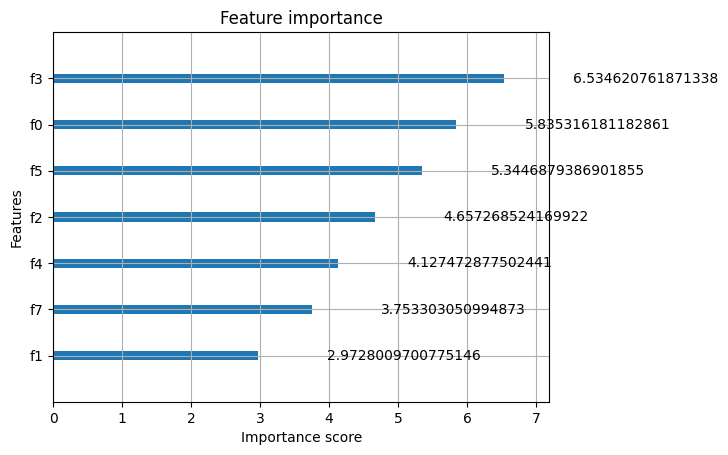


🎉 FINAL SUMMARY:
   Accuracy: 87.0% | Precision: 8.3%
   Recall:   0.7% | F1-Score:  1.4%
✅ COMPLETE!


In [ ]:
import os
import glob
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from sklearn.preprocessing import StandardScaler
import xgboost as xgb
import matplotlib.pyplot as plt
import librosa
from scipy import signal
from scipy.stats import skew, kurtosis

# Configuration
BASE_DIR = r"E:\Research Project (Prof. Preeti Rao)\Top 100 files by Wheeze count"
WAV_DIR = os.path.join(BASE_DIR, "*.wav")
TXT_DIR = os.path.join(BASE_DIR, "*_label_audacity.txt")

print("Finding WAV/TXT pairs...")
wav_files = sorted(glob.glob(WAV_DIR))
txt_files = sorted(glob.glob(TXT_DIR))

print(f"Found {len(wav_files)} WAV files, {len(txt_files)} TXT files")

# Pair WAV and TXT files (accounting for _label_audacity suffix)
pairs = []
wav_stems = {Path(w).stem: w for w in wav_files}
txt_stems = {Path(t).stem.replace('_label_audacity', ''): t for t in txt_files}

for base_stem, wav_path in wav_stems.items():
    if base_stem in txt_stems:
        txt_path = txt_stems[base_stem]
        pairs.append((wav_path, txt_path))
        print(f"Paired: {Path(wav_path).name} ↔ {Path(txt_path).name}")

print(f"Found {len(pairs)} valid WAV/TXT pairs")

# 80-20 split at file level
train_pairs, test_pairs = train_test_split(pairs, test_size=0.2, random_state=42)
print(f"Train: {len(train_pairs)} files, Test: {len(test_pairs)} files")

def parse_audacity_labels(txt_path):
    """Parse Audacity label format: start\tend\tlabel"""
    labels = []
    with open(txt_path, 'r') as f:
        for line in f:
            parts = line.strip().split('\t')
            if len(parts) == 3:
                start, end, label = parts
                try:
                    start = float(start)
                    end = float(end)
                    if 'Wheeze' in label:
                        labels.append((start, end, 1))
                    elif label in ['Silence', 'I', 'E']:  
                        labels.append((start, end, 0))
                except ValueError:
                    continue
    return labels

def get_label_at_window_start(labels, start_time):
    """Get label (0/1) at WINDOW START TIME (PDF requirement)"""
    for start, end, label in labels:
        if start <= start_time < end:
            return label
    return 0

def extract_shape_features(wav_path, txt_path, sr=16000):
    """Extract PDF-SPECIFIC shape features from 0.1s FFT windows"""
    audio, _ = librosa.load(wav_path, sr=sr)
    
    audacity_labels = parse_audacity_labels(txt_path)
    print(f"  📏 Audio: {len(audio)/sr:.1f}s, {len(audacity_labels)} intervals")
    
    if len(audacity_labels) == 0:
        return np.array([]), np.array([])
    
    win_len = int(0.1 * sr)
    hop_len = int(0.01 * sr)
    
    shape_features = []
    frame_labels = []
    
    for start_sample in range(0, len(audio) - win_len + 1, hop_len):
        window = audio[start_sample:start_sample + win_len]
        window_start_time = start_sample / sr
        
        # FFT SPECTRUM (PDF-style)
        fft_window = np.fft.rfft(window, n=1024)
        freqs = np.fft.rfftfreq(1024, 1/sr)
        S_mag = np.abs(fft_window)
        
        # PDF WHEEZE FEATURES
        global_max_amp = np.max(S_mag)
        global_max_freq = freqs[np.argmax(S_mag)]
        flux = np.mean(np.diff(np.log(S_mag + 1e-10)))
        low_freq_mask = freqs < 1000
        low_freq_energy = np.sum(S_mag[low_freq_mask]) / np.sum(S_mag)
        centroid = np.sum(S_mag * freqs) / (np.sum(S_mag) + 1e-10)
        rms = np.sqrt(np.mean(window**2))
        log_energy = np.log(np.sum(window**2) + 1e-10)
        
        f0 = librosa.yin(window, fmin=50, fmax=500, sr=sr)
        f0 = f0[f0 > 0]
        f0_trend = np.polyfit(np.arange(len(f0)), f0, 1)[0] if len(f0) > 10 else 0
        
        shape_vector = [
            np.log(global_max_amp + 1e-10),
            np.log(centroid + 1e-10),
            np.log(global_max_freq + 1e-10),
            np.log(1000 - global_max_freq + 1e-10),
            rms,
            log_energy,
            f0_trend,
            np.std(f0) if len(f0) > 0 else 0
        ]
        
        shape_features.append(shape_vector)
        frame_label = get_label_at_window_start(audacity_labels, window_start_time)
        frame_labels.append(frame_label)
    
    return np.array(shape_features), np.array(frame_labels)

# Extract features
print("\n🔄 Extracting PDF SPECTRUM features...")
train_features, train_labels = [], []
test_features, test_labels = [], []

for i, (wav, txt) in enumerate(train_pairs):
    feats, labs = extract_shape_features(wav, txt)
    if len(feats) > 0:
        train_features.append(feats)
        train_labels.append(labs)
        print(f"Train {i+1}: {Path(wav).name} → {feats.shape[0]} frames")

for i, (wav, txt) in enumerate(test_pairs):
    feats, labs = extract_shape_features(wav, txt)
    if len(feats) > 0:
        test_features.append(feats)
        test_labels.append(labs)
        print(f"Test {i+1}: {Path(wav).name} → {feats.shape[0]} frames")

if len(train_features) == 0 or len(test_features) == 0:
    print("❌ No valid data!")
else:
    X_train = np.vstack(train_features)
    y_train = np.hstack(train_labels)
    X_test = np.vstack(test_features)
    y_test = np.hstack(test_labels)

    print(f"\n📈 Dataset: Train {X_train.shape}, Test {X_test.shape}")
    print(f"⚖️ Wheeze: Train {y_train.mean():.1%}, Test {y_test.mean():.1%}")

    # Scale and train
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    model = xgb.XGBClassifier(n_estimators=300, max_depth=8, learning_rate=0.08,
                            subsample=0.85, colsample_bytree=0.85, random_state=42)
    model.fit(X_train_scaled, y_train)

    # Predictions
    y_pred = model.predict(X_test_scaled)
    y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]

    # ALL METRICS
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    print("\n" + "="*80)
    print("🎯 PDF SPECTRUM SHAPE WHEEZE DETECTION - COMPLETE METRICS")
    print("="*80)
    print(f"📊 ACCURACY:  {accuracy:.4f} ({accuracy:.1%})")
    print(f"✅ PRECISION: {precision:.4f} ({precision:.1%})")
    print(f"📈 RECALL:    {recall:.4f} ({recall:.1%})")
    print(f"🎯 F1-SCORE:  {f1:.4f} ({f1:.1%})")
    print(f"🔢 Test frames: {len(y_test)} ({y_test.sum()} Wheeze, {len(y_test)-y_test.sum()} Normal)")
    print("\n📊 Full Classification Report:")
    print(classification_report(y_test, y_pred, target_names=['Normal', 'Wheeze']))
    
    print("\n🔢 Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

    # Save results
    feature_names = ["log_globalMaxAmp", "spectralCentroid_log", "log_maxFreq", 
                    "log_lowFreqDist", "pcm_RMSenergy", "pcm_LOGenergy", 
                    "F0direction", "F0_std"]
    
    results_df = pd.DataFrame({
        'file': np.repeat([Path(p[0]).name for p in test_pairs], [len(f) for f in test_features]),
        'time_start_s': np.hstack([np.arange(0, len(f)*0.01, 0.01) for f in test_features]),
        'wheeze_prob': y_pred_proba,
        'wheeze_pred': y_pred,
        **{name: X_test_scaled[:, i] for i, name in enumerate(feature_names)}
    })
    results_df.to_csv('pdf_wheeze_predictions_01s.csv', index=False)
    
    # Summary metrics CSV
    metrics_df = pd.DataFrame({
        'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
        'Value': [accuracy, precision, recall, f1],
        'Value_Pct': [f"{accuracy:.1%}", f"{precision:.1%}", f"{recall:.1%}", f"{f1:.1%}"]
    })
    metrics_df.to_csv('wheeze_metrics_summary.csv', index=False)
    
    print(f"\n💾 Saved: pdf_wheeze_predictions_01s.csv + wheeze_metrics_summary.csv")

    # Feature importance
    plt.figure(figsize=(10, 6))
    xgb.plot_importance(model, importance_type='gain')
    plt.savefig('pdf_shape_importance.png', dpi=300, bbox_inches='tight')
    plt.show()

    print(f"\n🎉 FINAL SUMMARY:")
    print(f"   Accuracy: {accuracy:.1%} | Precision: {precision:.1%}")
    print(f"   Recall:   {recall:.1%} | F1-Score:  {f1:.1%}")
    print("✅ COMPLETE!")


In [1]:
import os
import glob
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from sklearn.preprocessing import StandardScaler
import xgboost as xgb
import matplotlib.pyplot as plt
import librosa
from scipy import signal
from scipy.stats import skew, kurtosis

In [ ]:
# Configuration
BASE_DIR = r"E:\Research Project (Prof. Preeti Rao)\Top 100 files by Wheeze count"
WAV_DIR = os.path.join(BASE_DIR, "*.wav")
TXT_DIR = os.path.join(BASE_DIR, "*_label_audacity.txt")

print("Finding WAV/TXT pairs...")
wav_files = sorted(glob.glob(WAV_DIR))
txt_files = sorted(glob.glob(TXT_DIR))

print(f"Found {len(wav_files)} WAV files, {len(txt_files)} TXT files")

🔍 Finding WAV/TXT pairs...
Found 100 WAV files, 100 TXT files


In [5]:
# Pair WAV and TXT files (accounting for _label_audacity suffix)
pairs = []
wav_stems = {Path(w).stem: w for w in wav_files}
txt_stems = {Path(t).stem.replace('_label_audacity', ''): t for t in txt_files}

for base_stem, wav_path in wav_stems.items():
    if base_stem in txt_stems:
        txt_path = txt_stems[base_stem]
        pairs.append((wav_path, txt_path))
        print(f"Paired: {Path(wav_path).name} ↔ {Path(txt_path).name}")

print(f"Found {len(pairs)} valid WAV/TXT pairs")

# 80-20 split at file level
train_pairs, test_pairs = train_test_split(pairs, test_size=0.2, random_state=42)
print(f"Train: {len(train_pairs)} files, Test: {len(test_pairs)} files")

Paired: steth_20181001_11_01_50.wav ↔ steth_20181001_11_01_50_label_audacity.txt
Paired: steth_20181001_11_02_11.wav ↔ steth_20181001_11_02_11_label_audacity.txt
Paired: steth_20181001_11_02_53.wav ↔ steth_20181001_11_02_53_label_audacity.txt
Paired: steth_20181001_11_16_47.wav ↔ steth_20181001_11_16_47_label_audacity.txt
Paired: steth_20181001_11_17_28.wav ↔ steth_20181001_11_17_28_label_audacity.txt
Paired: steth_20181017_12_47_54.wav ↔ steth_20181017_12_47_54_label_audacity.txt
Paired: steth_20181108_16_39_41.wav ↔ steth_20181108_16_39_41_label_audacity.txt
Paired: steth_20181108_16_40_02.wav ↔ steth_20181108_16_40_02_label_audacity.txt
Paired: steth_20181108_16_40_26.wav ↔ steth_20181108_16_40_26_label_audacity.txt
Paired: steth_20181110_17_30_23.wav ↔ steth_20181110_17_30_23_label_audacity.txt
Paired: steth_20181115_15_21_58.wav ↔ steth_20181115_15_21_58_label_audacity.txt
Paired: steth_20181210_09_03_07.wav ↔ steth_20181210_09_03_07_label_audacity.txt
Paired: steth_20181210_09_03

In [ ]:
def parse_audacity_labels(txt_path):
    """Parse Audacity label format: start\tend\tlabel"""
    labels = []
    with open(txt_path, 'r') as f:
        for line in f:
            parts = line.strip().split('\t')
            if len(parts) == 3:
                start, end, label = parts
                try:
                    start = float(start)
                    end = float(end)
                    if 'Wheeze' in label:
                        labels.append((start, end, 1))
                    elif label in ['Silence', 'I', 'E']:  
                        labels.append((start, end, 0))
                except ValueError:
                    continue
    return labels

def get_label_at_window_start(labels, start_time):
    """Get label (0/1) at WINDOW START TIME"""
    for start, end, label in labels:
        if start <= start_time < end:
            return label
    return 0

def extract_shape_features(wav_path, txt_path, sr=16000):
    """Extract PDF-SPECIFIC shape features from 0.1s FFT windows"""
    audio, _ = librosa.load(wav_path, sr=sr)
    
    audacity_labels = parse_audacity_labels(txt_path)
    print(f"  Audio: {len(audio)/sr:.1f}s, {len(audacity_labels)} intervals")
    
    if len(audacity_labels) == 0:
        return np.array([]), np.array([])
    
    win_len = int(0.1 * sr)
    hop_len = int(0.01 * sr)
    
    shape_features = []
    frame_labels = []
    
    for start_sample in range(0, len(audio) - win_len + 1, hop_len):
        window = audio[start_sample:start_sample + win_len]
        window_start_time = start_sample / sr
        
        # FFT SPECTRUM (PDF-style)
        fft_window = np.fft.rfft(window, n=1024)
        freqs = np.fft.rfftfreq(1024, 1/sr)
        S_mag = np.abs(fft_window)
        
        # PDF WHEEZE FEATURES
        global_max_amp = np.max(S_mag)
        global_max_freq = freqs[np.argmax(S_mag)]
        flux = np.mean(np.diff(np.log(S_mag + 1e-10)))
        low_freq_mask = freqs < 1000
        low_freq_energy = np.sum(S_mag[low_freq_mask]) / np.sum(S_mag)
        centroid = np.sum(S_mag * freqs) / (np.sum(S_mag) + 1e-10)
        rms = np.sqrt(np.mean(window**2))
        log_energy = np.log(np.sum(window**2) + 1e-10)
        
        f0 = librosa.yin(window, fmin=50, fmax=500, sr=sr)
        f0 = f0[f0 > 0]
        f0_trend = np.polyfit(np.arange(len(f0)), f0, 1)[0] if len(f0) > 10 else 0
        
        shape_vector = [
            np.log(global_max_amp + 1e-10),
            np.log(centroid + 1e-10),
            np.log(global_max_freq + 1e-10),
            np.log(1000 - global_max_freq + 1e-10),
            rms,
            log_energy,
            f0_trend,
            np.std(f0) if len(f0) > 0 else 0
        ]
        
        shape_features.append(shape_vector)
        frame_label = get_label_at_window_start(audacity_labels, window_start_time)
        frame_labels.append(frame_label)
    
    return np.array(shape_features), np.array(frame_labels)


Extracting PDF SPECTRUM features...
  Audio: 15.0s, 33 intervals


C:\Users\HP\AppData\Local\Temp\ipykernel_12348\78373435.py:67: RuntimeWarning: invalid value encountered in log
  np.log(1000 - global_max_freq + 1e-10),


Train 1: steth_20190711_10_46_35.wav → 1491 frames
  Audio: 15.0s, 38 intervals
Train 2: trunc_2019-05-31-15-38-07-L2_10.wav → 1491 frames
  Audio: 15.0s, 29 intervals
Train 3: steth_20190118_13_26_56.wav → 1491 frames
  Audio: 15.0s, 22 intervals
Train 4: steth_20190516_14_49_03.wav → 1491 frames
  Audio: 15.0s, 38 intervals
Train 5: trunc_2019-05-31-14-07-30-L1_13.wav → 1491 frames
  Audio: 15.0s, 20 intervals
Train 6: steth_20181210_12_27_55.wav → 1491 frames
  Audio: 15.0s, 9 intervals
Train 7: steth_20190228_09_54_30.wav → 1491 frames
  Audio: 15.0s, 25 intervals
Train 8: trunc_2019-07-16-11-11-47-L1_3.wav → 1491 frames
  Audio: 15.0s, 24 intervals
Train 9: steth_20181110_17_30_23.wav → 1491 frames
  Audio: 15.0s, 29 intervals
Train 10: trunc_2019-05-31-14-07-30-L4_12.wav → 1491 frames
  Audio: 15.0s, 37 intervals
Train 11: steth_20181210_09_03_07.wav → 1491 frames
  Audio: 15.0s, 32 intervals
Train 12: steth_20190531_14_11_47.wav → 1491 frames
  Audio: 15.0s, 36 intervals
Train 1

<Figure size 1000x600 with 0 Axes>

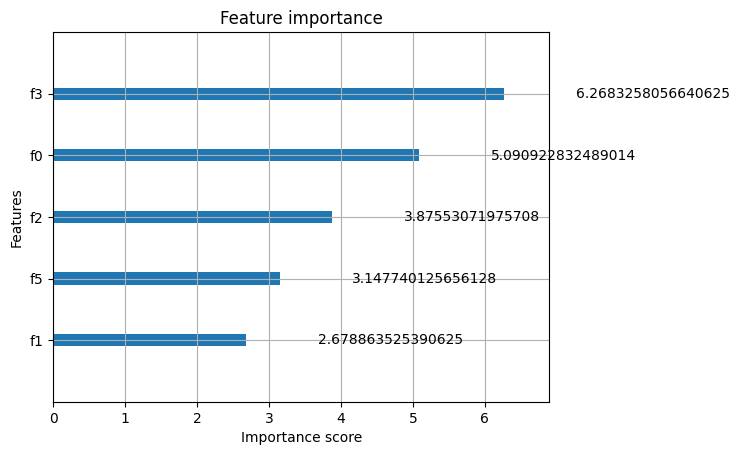


FINAL SUMMARY:
Accuracy: 87.0% | Precision: 7.1%
Recall:   0.6% | F1-Score:  1.2%
COMPLETE!


In [ ]:
# Extract features
print("\nExtracting SPECTRUM features...")
train_features, train_labels = [], []
test_features, test_labels = [], []

for i, (wav, txt) in enumerate(train_pairs):
    feats, labs = extract_shape_features(wav, txt)
    if len(feats) > 0:
        train_features.append(feats)
        train_labels.append(labs)
        print(f"Train {i+1}: {Path(wav).name} → {feats.shape[0]} frames")

for i, (wav, txt) in enumerate(test_pairs):
    feats, labs = extract_shape_features(wav, txt)
    if len(feats) > 0:
        test_features.append(feats)
        test_labels.append(labs)
        print(f"Test {i+1}: {Path(wav).name} → {feats.shape[0]} frames")

if len(train_features) == 0 or len(test_features) == 0:
    print("No valid data!")
else:
    X_train = np.vstack(train_features)
    y_train = np.hstack(train_labels)
    X_test = np.vstack(test_features)
    y_test = np.hstack(test_labels)

    print(f"\nDataset: Train {X_train.shape}, Test {X_test.shape}")
    print(f"Wheeze: Train {y_train.mean():.1%}, Test {y_test.mean():.1%}")

    # Scale and train
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    model = xgb.XGBClassifier(n_estimators=300, max_depth=8, learning_rate=0.08,
                            subsample=0.85, colsample_bytree=0.85, random_state=42)
    model.fit(X_train_scaled, y_train)

    # Predictions
    y_pred = model.predict(X_test_scaled)
    y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]

    # ALL METRICS
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    print("\n" + "="*80)
    print("PDF SPECTRUM SHAPE WHEEZE DETECTION - COMPLETE METRICS")
    print("="*80)
    print(f"ACCURACY:  {accuracy:.4f} ({accuracy:.1%})")
    print(f"PRECISION: {precision:.4f} ({precision:.1%})")
    print(f"RECALL:    {recall:.4f} ({recall:.1%})")
    print(f"F1-SCORE:  {f1:.4f} ({f1:.1%})")
    print(f"Test frames: {len(y_test)} ({y_test.sum()} Wheeze, {len(y_test)-y_test.sum()} Normal)")
    print("\nFull Classification Report:")
    print(classification_report(y_test, y_pred, target_names=['Normal', 'Wheeze']))
    
    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

    # Save results
    feature_names = ["log_globalMaxAmp", "spectralCentroid_log", "log_maxFreq", 
                    "log_lowFreqDist", "F0direction", "F0_std"]
    
    results_df = pd.DataFrame({
        'file': np.repeat([Path(p[0]).name for p in test_pairs], [len(f) for f in test_features]),
        'time_start_s': np.hstack([np.arange(0, len(f)*0.01, 0.01) for f in test_features]),
        'wheeze_prob': y_pred_proba,
        'wheeze_pred': y_pred,
        **{name: X_test_scaled[:, i] for i, name in enumerate(feature_names)}
    })
    results_df.to_csv('pdf_wheeze_predictions_01s.csv', index=False)

    # Summary metrics CSV
    metrics_df = pd.DataFrame({
        'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
        'Value': [accuracy, precision, recall, f1],
        'Value_Pct': [f"{accuracy:.1%}", f"{precision:.1%}", f"{recall:.1%}", f"{f1:.1%}"]
    })
    metrics_df.to_csv('wheeze_metrics_summary.csv', index=False)
    
    print(f"\n Saved: pdf_wheeze_predictions_01s.csv + wheeze_metrics_summary.csv")

    # Feature importance
    plt.figure(figsize=(10, 6))
    xgb.plot_importance(model, importance_type='gain')
    plt.savefig('pdf_shape_importance.png', dpi=300, bbox_inches='tight')
    plt.show()

    print(f"\nFINAL SUMMARY:")
    print(f"Accuracy: {accuracy:.1%} | Precision: {precision:.1%}")
    print(f"Recall:   {recall:.1%} | F1-Score:  {f1:.1%}")
    print("COMPLETE!")